# UrbanNest Health Analytics — Predicting Medical Insurance Charges

**Business problem:** UrbanNest Health Analytics works with insurance providers who currently set
prices using rough assumptions rather than data. This leads to some customers being overcharged
and others undercharged — hurting both customer trust and company profit.

**Goal of this notebook:** Use patient data (age, sex, BMI, number of children, smoking status,
region) to build a Linear Regression model that predicts insurance charges. A data-driven model
lets UrbanNest price policies more fairly and consistently, and tells the business which patient
factors actually drive cost.

**Workflow:** load & inspect data → clean it → explore it (EDA) → prepare features → train a
model → evaluate it → interpret what it means for the business.

## Step 1: Load and inspect the data
First we bring the dataset into Python and take a first look — shape, column names, data types — before touching anything.

In [ ]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**A note on the charts below:** Most of our key charts (smoker cost, BMI category, age
group, the BMI+smoker combo, and the model coefficients) have been redesigned in a consistent,
presentation-ready style for better visualization, and one consistent navy/amber color scheme. The style is defined once below and reused
in each of those charts.

In [ ]:
# Define reusable colors and styling helpers for the charts below
import matplotlib.ticker as mticker

# ---- Shared "presentation-ready" chart style, reused across the key charts below ----
NAVY, STEEL, AMBER = "#13315C", "#4C7EA8", "#E0793C"
GRID, TEXT, MUTED = "#E4E7EB", "#2B2F36", "#6B7280"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "text.color": TEXT,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
})

def style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.grid(axis="y", color=GRID, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(left=False, bottom=False)

def chart_title(ax, headline, subtitle):
    ax.text(0, 1.20, headline, transform=ax.transAxes, fontsize=13.5, fontweight="bold", color=NAVY)
    ax.text(0, 1.10, subtitle, transform=ax.transAxes, fontsize=10, color=MUTED)

In [ ]:
# Load the raw dataset
df = pd.read_csv('insurance_cleaned.csv')

In [ ]:
# Peek at the first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Check the number of rows and columns
df.shape

(1337, 7)

In [ ]:
# List the column names
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

`df.info()` tells us the data types of each column and whether any values are missing (non-null counts). This is the first health-check on the dataset.

In [ ]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.2+ KB


`describe()` gives summary statistics (mean, min, max, quartiles) for the numeric columns — age, BMI, children, charges — so we get a feel for typical patient profiles and cost ranges before modeling.

In [ ]:
# Summary stats for the numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


`describe(include="object")` does the same thing for the categorical columns (sex, smoker, region), showing how many unique categories exist and which one appears most often.

In [ ]:
# Summary stats for the categorical columns
df.describe(include="object")

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


## Step 2: Clean the data
We check for missing values and duplicate rows before doing anything else.

In [ ]:
# Count missing values per column
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# View the duplicate rows
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges


No missing values were found, which is good. `df_clean` is a working copy of the raw data so the original `df` stays untouched if we need to compare later.

In [ ]:
# Make a working copy of the data
df_clean = df.copy()

In [ ]:
# Re-check missing values on the copy
df_clean.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
# Check for duplicate rows
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
# View the duplicate rows again
df_clean[df_clean.duplicated()]

,age,sex,bmi,children,smoker,region,charges


In [ ]:
# Confirm the duplicate count before dropping
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
# Drop the duplicate rows
df_clean.drop_duplicates(inplace=True)

In [ ]:
# Confirm duplicates are gone
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
# Reset the row index after dropping duplicates
df_clean.reset_index(drop=True, inplace=True)

Quick check on the categorical columns — confirming sex, smoker, and region only contain the categories we expect (no typos or unexpected values that would break the model later).

In [ ]:
# Check the categories in each text column
for column in ["sex", "smoker", "region"]:
    print(f"\n{column.upper()}")
    print(df_clean[column].value_counts())


SEX
sex
male      675
female    662
Name: count, dtype: int64

SMOKER
smoker
no     1063
yes     274
Name: count, dtype: int64

REGION
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


In [ ]:
# Quick stats recap for the key numeric columns
df_clean[["age", "bmi", "children", "charges"]].describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
# Print a final cleaning summary
print("Dataset shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

df_clean.head()

Dataset shape: (1337, 7)
Missing values: 0
Duplicate rows: 0


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Full numeric summary stats on the cleaned data
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


In [ ]:
# Full categorical summary stats on the cleaned data
df_clean.describe(include="object")

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


## Step 3: Explore the data (EDA)
Now that our data is clean, we look for patterns — which patient characteristics actually move
insurance charges, and by how much. Each chart below is explained in plain terms.

**Distribution of charges:** most patients have relatively low charges, but there's a long tail of
very high charges. In healthcare-cost terms, this usually means a small group of patients
(often smokers or people with high BMI) drive costs much higher than the "typical" patient, exactly the kind of pattern a flat/average-based pricing system misses.

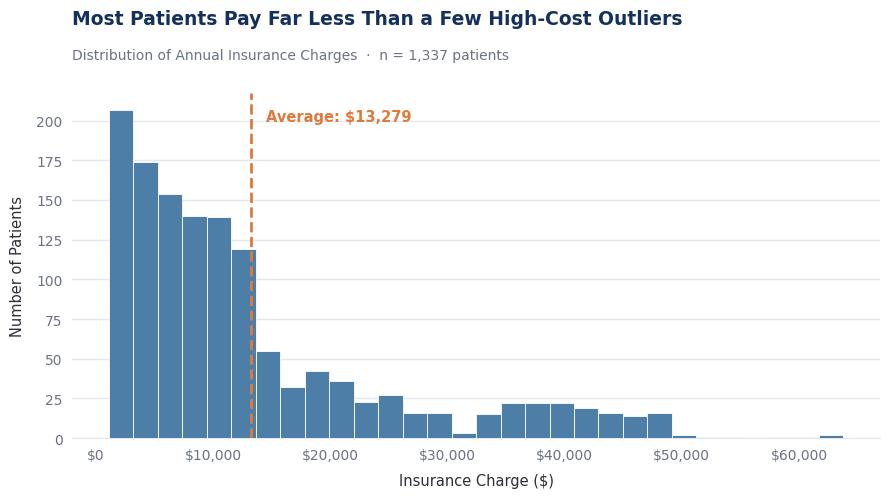

In [ ]:
# Plot the distribution of charges
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.hist(df_clean["charges"], bins=30, color=STEEL, edgecolor="white", linewidth=0.6, zorder=3)

mean_val = df_clean["charges"].mean()
ax.axvline(mean_val, color=AMBER, linewidth=2, linestyle="--", zorder=4)
ax.text(mean_val + df_clean["charges"].max() * 0.02, ax.get_ylim()[1] * 0.92,
        f"Average: ${mean_val:,.0f}", color=AMBER, fontsize=10.5, fontweight="bold")

style_axes(ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
chart_title(ax, "Most Patients Pay Far Less Than a Few High-Cost Outliers",
            f"Distribution of Annual Insurance Charges  ·  n = {len(df_clean):,} patients")
ax.set_xlabel("Insurance Charge ($)", fontsize=10.5, labelpad=8)
ax.set_ylabel("Number of Patients", fontsize=10.5, labelpad=8)

plt.tight_layout()
plt.show()

**Smoking vs. charges:** grouping by smoker status shows the average charge for each group. This directly answers one of UrbanNest's key business questions.

In [ ]:
# Average charge for smokers vs non-smokers
smoker_charges = (
    df_clean.groupby("smoker")["charges"]
    .mean()
    .sort_values(ascending=False)
)

smoker_charges

,charges
smoker,
yes,32050.231832
no,8440.660307


The bar chart makes it visual: smokers cost insurers noticeably more on average than non-smokers. This is usually the single biggest cost driver in health insurance data, and it's the clearest justification for smoker-based pricing tiers.

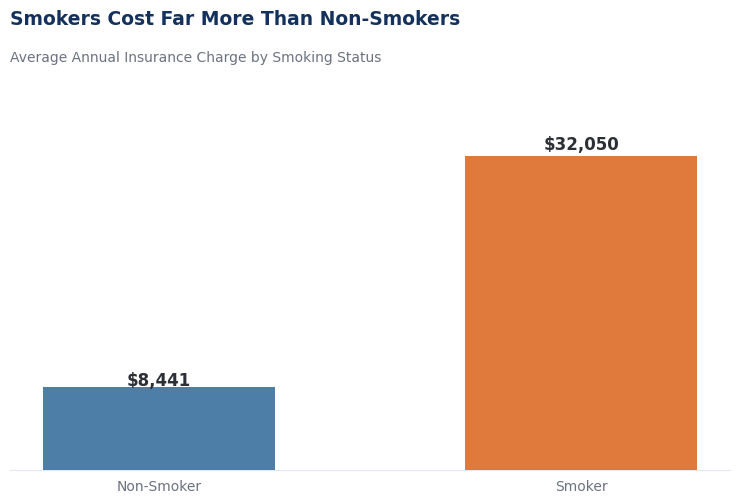

In [ ]:
# Plot average charge by smoking status
plot_data = smoker_charges.reindex(["no", "yes"])
labels = ["Non-Smoker", "Smoker"]
colors = [STEEL, AMBER]

fig, ax = plt.subplots(figsize=(7.5, 5.2))
bars = ax.bar(labels, plot_data.values, color=colors, width=0.55, zorder=3)

for bar, val in zip(bars, plot_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + val*0.02, f"${val:,.0f}",
            ha="center", fontsize=12, fontweight="bold", color=TEXT)

style_axes(ax)
ax.set_yticks([])
chart_title(ax, "Smokers Cost Far More Than Non-Smokers",
            "Average Annual Insurance Charge by Smoking Status")
ax.set_ylim(0, plot_data.values.max() * 1.18)

plt.tight_layout()
plt.show()

**Boxplot of charges by smoker:** a different view of the same smoker-cost gap seen earlier — boxplots are useful here because they also show the spread and outliers within each group, not just the average.

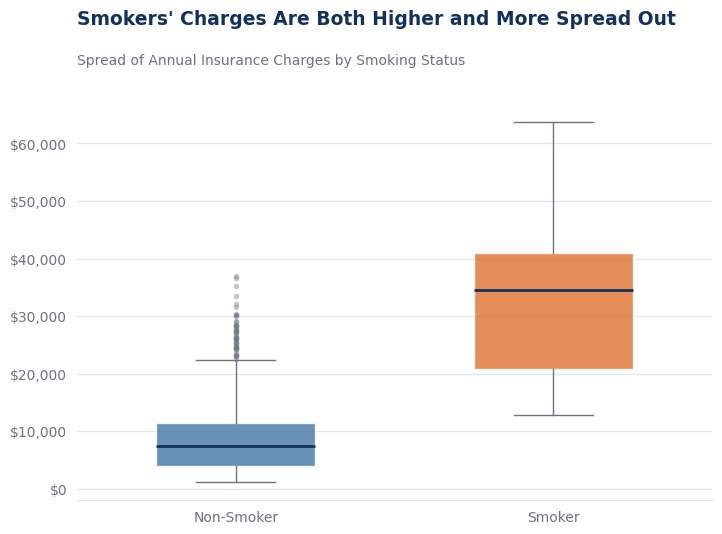

In [ ]:
# Plot charge spread by smoking status
groups = [df_clean.loc[df_clean["smoker"] == "no", "charges"],
          df_clean.loc[df_clean["smoker"] == "yes", "charges"]]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
bp = ax.boxplot(groups, tick_labels=["Non-Smoker", "Smoker"], patch_artist=True, widths=0.5,
                 medianprops=dict(color=NAVY, linewidth=2),
                 whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                 flierprops=dict(marker="o", markerfacecolor=MUTED, markersize=4,
                                  alpha=0.4, markeredgecolor="none"))
for patch, color in zip(bp["boxes"], [STEEL, AMBER]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor("white")

style_axes(ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
chart_title(ax, "Smokers' Charges Are Both Higher and More Spread Out",
            "Spread of Annual Insurance Charges by Smoking Status")

plt.tight_layout()
plt.show()

**Age vs. charges:** a scatter plot to see whether cost rises steadily with age, as we'd expect from general health-risk trends.

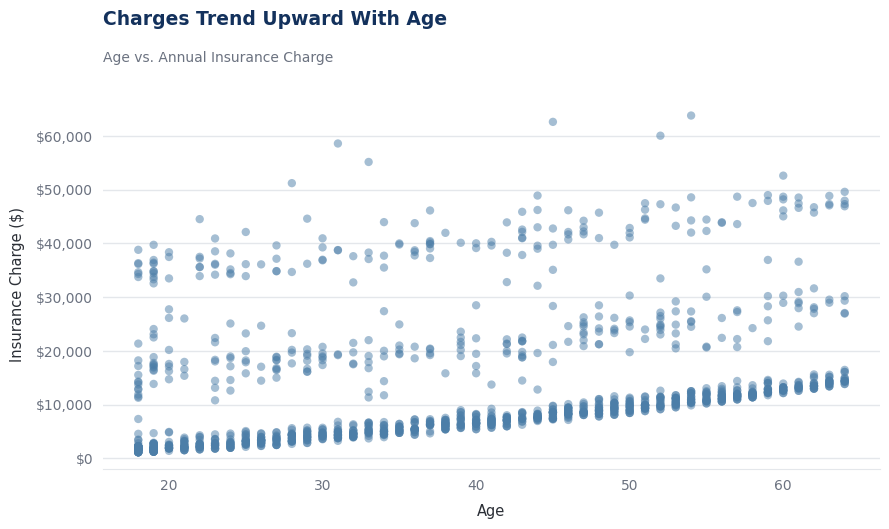

In [ ]:
# Plot age vs charges
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(df_clean["age"], df_clean["charges"], alpha=0.5, color=STEEL, edgecolor="none", zorder=3)

style_axes(ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
chart_title(ax, "Charges Trend Upward With Age", "Age vs. Annual Insurance Charge")
ax.set_xlabel("Age", fontsize=10.5, labelpad=8)
ax.set_ylabel("Insurance Charge ($)", fontsize=10.5, labelpad=8)

plt.tight_layout()
plt.show()

Splitting the same scatter plot by smoking status shows something important: charges rise with age for *both* groups, but smokers sit on a consistently higher band than non-smokers at almost every age. Age and smoking status appear to combine, not just add up separately.

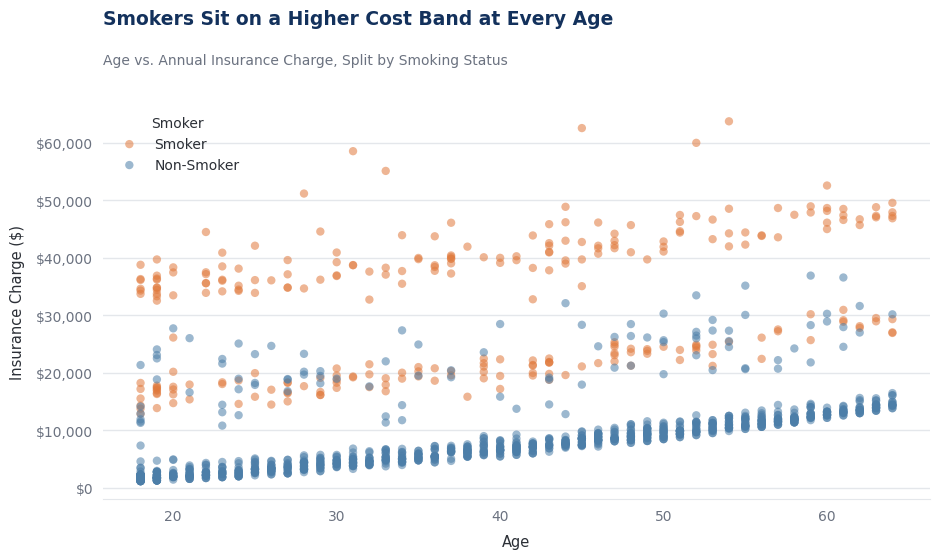

In [ ]:
# Plot age vs charges, split by smoker
fig, ax = plt.subplots(figsize=(9.5, 5.8))
color_map = {"no": STEEL, "yes": AMBER}
label_map = {"no": "Non-Smoker", "yes": "Smoker"}

for status in df_clean["smoker"].unique():
    subset = df_clean[df_clean["smoker"] == status]
    ax.scatter(subset["age"], subset["charges"], alpha=0.55, color=color_map[status],
               edgecolor="none", label=label_map[status], zorder=3)

style_axes(ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
chart_title(ax, "Smokers Sit on a Higher Cost Band at Every Age",
            "Age vs. Annual Insurance Charge, Split by Smoking Status")
ax.set_xlabel("Age", fontsize=10.5, labelpad=8)
ax.set_ylabel("Insurance Charge ($)", fontsize=10.5, labelpad=8)
ax.legend(frameon=False, loc="upper left", fontsize=10, title="Smoker")

plt.tight_layout()
plt.show()

A correlation number close to 0 means little linear relationship; closer to 1 means a strong one. This quantifies how strongly age alone predicts charges (independent of other factors).

In [ ]:
# Correlation between age and charges
df_clean["age"].corr(df_clean["charges"])

np.float64(0.2983082125097864)

**BMI vs. charges:** checking whether higher body mass index tends to come with higher insurance costs, which is expected since BMI relates to several health risks.

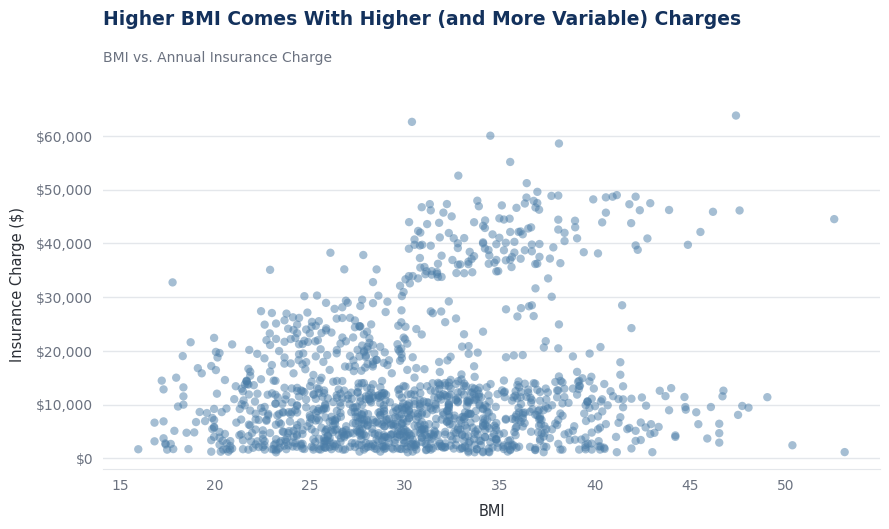

In [ ]:
# Plot BMI vs charges
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(df_clean["bmi"], df_clean["charges"], alpha=0.5, color=STEEL, edgecolor="none", zorder=3)

style_axes(ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
chart_title(ax, "Higher BMI Comes With Higher (and More Variable) Charges",
            "BMI vs. Annual Insurance Charge")
ax.set_xlabel("BMI", fontsize=10.5, labelpad=8)
ax.set_ylabel("Insurance Charge ($)", fontsize=10.5, labelpad=8)

plt.tight_layout()
plt.show()

The correlation coefficient here summarizes that relationship as a single number — useful for comparing BMI's influence against age's influence later.

In [ ]:
# Correlation between BMI and charges
df_clean[["bmi", "charges"]].corr()

,bmi,charges
bmi,1.000000,0.198401
charges,0.198401,1.000000


To make BMI easier to interpret for the business (rather than a raw number), we bucket it into standard clinical categories: Underweight, Normal, Overweight, Obese.

In [ ]:
# Create BMI category buckets
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df_clean["bmi_category"] = df_clean["bmi"].apply(bmi_category)

In [ ]:
# Count patients per BMI category
df_clean["bmi_category"].value_counts()

,count
bmi_category,
Obese,706
Overweight,386
Normal,225
Underweight,20


In [ ]:
# Average charge per BMI category
bmi_charges = df_clean.groupby("bmi_category")["charges"].mean().round(2)

bmi_charges

,charges
bmi_category,
Normal,10409.34
Obese,15572.04
Overweight,10987.51
Underweight,8852.20


**BMI category vs. average charges:** this shows whether the *obese* category in particular stands out — often the case, since obesity is linked to several costly health conditions.

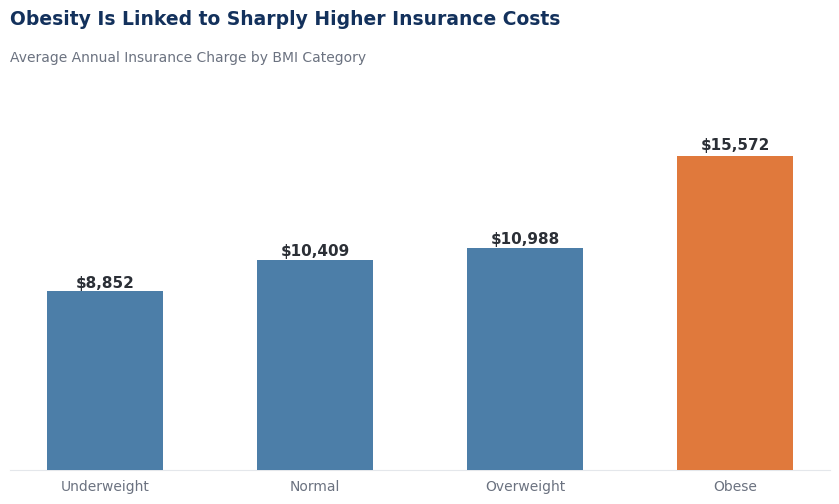

In [ ]:
# Plot average charge by BMI category
bmi_order = ["Underweight", "Normal", "Overweight", "Obese"]
bmi_charges = (
    df_clean.groupby("bmi_category")["charges"]
    .mean()
    .reindex(bmi_order)
)

colors = [AMBER if cat == "Obese" else STEEL for cat in bmi_charges.index]

fig, ax = plt.subplots(figsize=(8.5, 5.2))
bars = ax.bar(bmi_charges.index, bmi_charges.values, color=colors, width=0.55, zorder=3)

for bar, val in zip(bars, bmi_charges.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + val*0.02, f"${val:,.0f}",
            ha="center", fontsize=11, fontweight="bold", color=TEXT)

style_axes(ax)
ax.set_yticks([])
chart_title(ax, "Obesity Is Linked to Sharply Higher Insurance Costs",
            "Average Annual Insurance Charge by BMI Category")
ax.set_ylim(0, bmi_charges.values.max() * 1.18)

plt.tight_layout()
plt.show()

In [ ]:
# View the ordered BMI category averages
bmi_charges.round(2)

,charges
bmi_category,
Underweight,8852.20
Normal,10409.34
Overweight,10987.51
Obese,15572.04


**Sex vs. charges:** checking whether average charges differ meaningfully between male and female patients.

In [ ]:
# Average charge by sex
sex_charges = df_clean.groupby("sex")["charges"].mean().round(2)

sex_charges

,charges
sex,
female,12569.58
male,13975.00


If this gap is small, it's a useful finding on its own: it suggests sex isn't a major cost driver here, which matters for fair-pricing purposes (many regions also restrict or scrutinize pricing by sex).

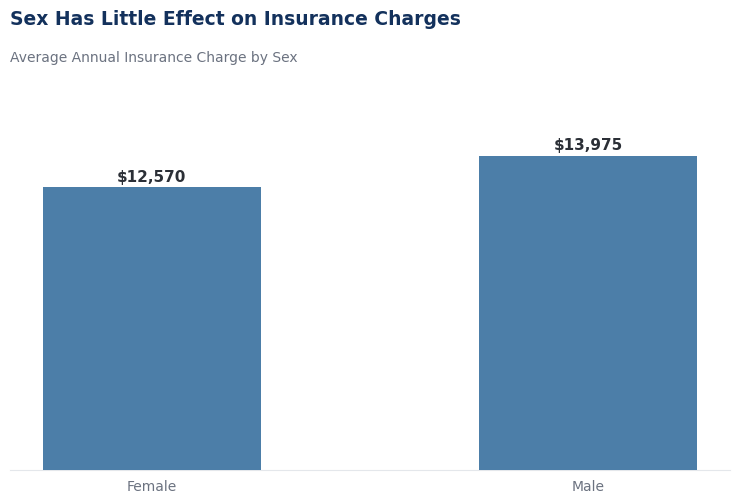

In [ ]:
# Plot average charge by sex
fig, ax = plt.subplots(figsize=(7.5, 5.2))
bars = ax.bar(sex_charges.index.str.title(), sex_charges.values, color=STEEL, width=0.5, zorder=3)

for bar, val in zip(bars, sex_charges.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + val*0.02, f"${val:,.0f}",
            ha="center", fontsize=11, fontweight="bold", color=TEXT)

style_axes(ax)
ax.set_yticks([])
chart_title(ax, "Sex Has Little Effect on Insurance Charges",
            "Average Annual Insurance Charge by Sex")
ax.set_ylim(0, sex_charges.values.max() * 1.18)

plt.tight_layout()
plt.show()

**Number of children vs. charges:** checking whether having more dependents on a policy relates to higher costs.

In [ ]:
# Average charge by number of children
children_charges = df_clean.groupby("children")["charges"].mean().round(2)

children_charges

,charges
children,
0,12384.70
1,12731.17
2,15073.56
3,15355.32
4,13850.66
5,8786.04


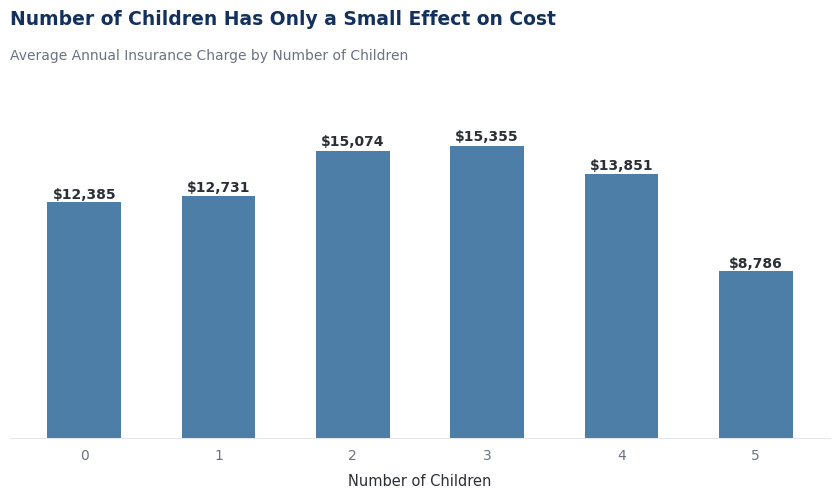

In [ ]:
# Plot average charge by number of children
fig, ax = plt.subplots(figsize=(8.5, 5.2))
bars = ax.bar(children_charges.index.astype(str), children_charges.values, color=STEEL, width=0.55, zorder=3)

for bar, val in zip(bars, children_charges.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + val*0.02, f"${val:,.0f}",
            ha="center", fontsize=10, fontweight="bold", color=TEXT)

style_axes(ax)
ax.set_yticks([])
chart_title(ax, "Number of Children Has Only a Small Effect on Cost",
            "Average Annual Insurance Charge by Number of Children")
ax.set_xlabel("Number of Children", fontsize=10.5, labelpad=8)
ax.set_ylim(0, children_charges.values.max() * 1.18)

plt.tight_layout()
plt.show()

In [ ]:
# Count patients per number of children
df_clean["children"].value_counts().sort_index()

,count
children,
0,573
1,324
2,240
3,157
4,25
5,18


**Region vs. charges:** checking whether where a patient lives affects their charges could reflect regional differences in healthcare cost-of-service.

In [ ]:
# Average charge by region
region_charges = (
    df_clean.groupby("region")["charges"]
    .mean().round(2)
    .sort_values(ascending=False)
)

region_charges

,charges
region,
southeast,14735.41
northeast,13406.38
northwest,12450.84
southwest,12346.94


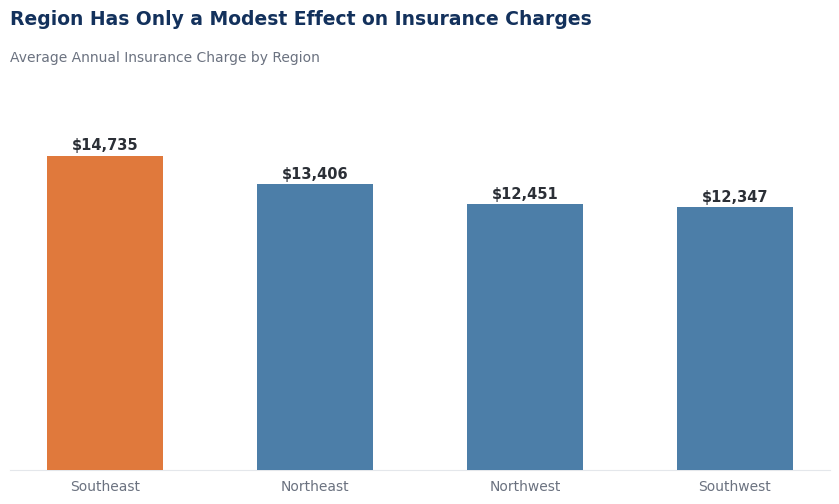

In [ ]:
# Plot average charge by region
fig, ax = plt.subplots(figsize=(8.5, 5.2))
colors = [AMBER if v == region_charges.values.max() else STEEL for v in region_charges.values]
bars = ax.bar(region_charges.index.str.title(), region_charges.values, color=colors, width=0.55, zorder=3)

for bar, val in zip(bars, region_charges.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + val*0.02, f"${val:,.0f}",
            ha="center", fontsize=10.5, fontweight="bold", color=TEXT)

style_axes(ax)
ax.set_yticks([])
chart_title(ax, "Region Has Only a Modest Effect on Insurance Charges",
            "Average Annual Insurance Charge by Region")
ax.set_ylim(0, region_charges.values.max() * 1.18)

plt.tight_layout()
plt.show()

**Age groups:** bucketing continuous age into bands makes the age-vs-cost pattern easier to read and easier to explain to non-technical stakeholders than a raw scatter plot.

In [ ]:
# Create age group buckets
bins = [17, 25, 35, 45, 55, 65]
labels = ["18-25", "26-35", "36-45", "46-55", "56-64"]

df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=bins,
    labels=labels
)

In [ ]:
# Count patients per age group
df_clean["age_group"].value_counts().sort_index()

,count
age_group,
18-25,305
26-35,268
36-45,264
46-55,284
56-64,216


In [ ]:
# Average charge per age group
age_charges = (
    df_clean.groupby("age_group", observed=False)["charges"]
    .mean().round(2)
)

age_charges

,charges
age_group,
18-25,9111.43
26-35,10495.16
36-45,13493.49
46-55,15986.90
56-64,18795.99


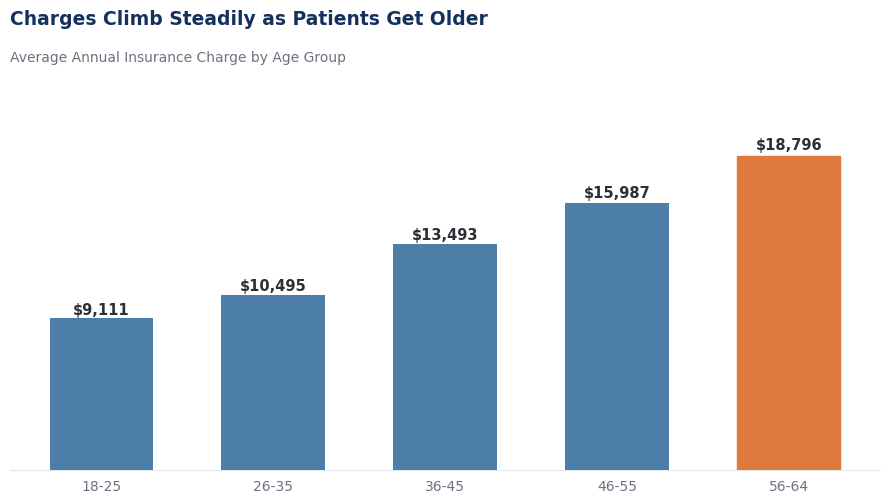

In [ ]:
# Plot average charge by age group
x_labels = age_charges.index.astype(str)
values = age_charges.values

fig, ax = plt.subplots(figsize=(9, 5.2))
bars = ax.bar(x_labels, values, color=STEEL, width=0.6, zorder=3)

# Highlight the highest-cost age band
bars[values.argmax()].set_color(AMBER)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + val*0.02, f"${val:,.0f}",
            ha="center", fontsize=10.5, fontweight="bold", color=TEXT)

style_axes(ax)
ax.set_yticks([])
chart_title(ax, "Charges Climb Steadily as Patients Get Older",
            "Average Annual Insurance Charge by Age Group")
ax.set_ylim(0, values.max() * 1.18)

plt.tight_layout()
plt.show()

**Combining BMI category and smoking status:** this cross-tab is one of the most important business findings — it checks whether being *both* obese *and* a smoker multiplies the cost impact rather than just adding two separate effects.

In [ ]:
# Average charge by BMI category and smoking status
smoker_bmi = (
    df_clean.groupby(["bmi_category", "smoker"], observed=False)["charges"]
    .mean().round(2)
    .unstack()
)

smoker_bmi

smoker,no,yes
bmi_category,,
Normal,7685.66,19942.22
Obese,8855.53,41557.99
Overweight,8257.96,22495.87
Underweight,5532.99,18809.82


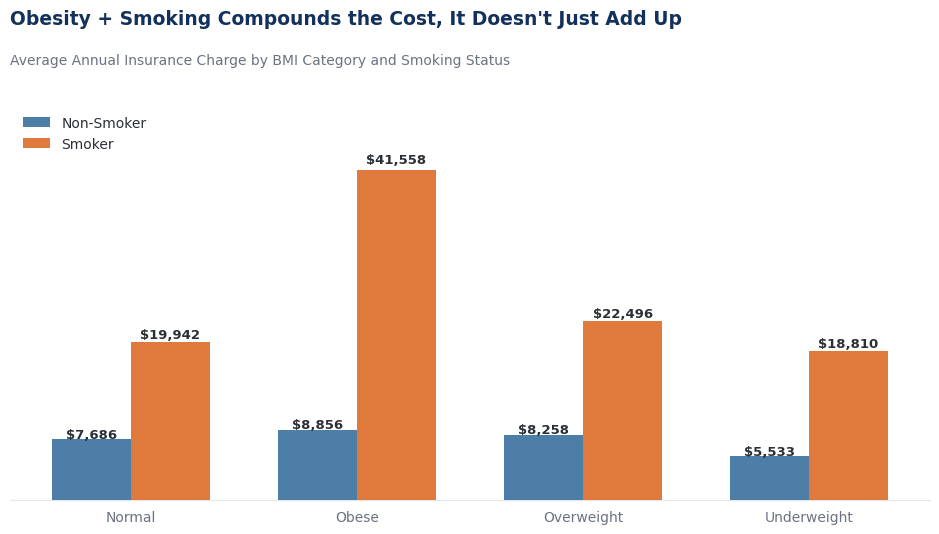

In [ ]:
# Plot the BMI category + smoking status combo
categories = smoker_bmi.index.astype(str)
no_vals = smoker_bmi["no"].values
yes_vals = smoker_bmi["yes"].values

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9.5, 5.5))
bars1 = ax.bar(x - width/2, no_vals, width, label="Non-Smoker", color=STEEL, zorder=3)
bars2 = ax.bar(x + width/2, yes_vals, width, label="Smoker", color=AMBER, zorder=3)

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + h*0.02, f"${h:,.0f}",
                ha="center", fontsize=9.5, fontweight="bold", color=TEXT)

ax.set_xticks(x)
ax.set_xticklabels(categories)

style_axes(ax)
ax.set_yticks([])
chart_title(ax, "Obesity + Smoking Compounds the Cost, It Doesn't Just Add Up",
            "Average Annual Insurance Charge by BMI Category and Smoking Status")
ax.legend(frameon=False, loc="upper left", fontsize=10)
ax.set_ylim(0, max(yes_vals.max(), no_vals.max()) * 1.2)

plt.tight_layout()
plt.show()

**Correlation matrix:** summarizes how every numeric variable relates to every other one in a single table. This is a quick way to see which features are most worth including in the model.

In [ ]:
# Correlation matrix for the numeric columns
numeric_columns = ["age", "bmi", "children", "charges"]

correlation = df_clean[numeric_columns].corr().round(2)

correlation

,age,bmi,children,charges
age,1.00,0.11,0.04,0.30
bmi,0.11,1.00,0.01,0.20
children,0.04,0.01,1.00,0.07
charges,0.30,0.20,0.07,1.00


The heatmap is the same information as a picture — darker/more intense colors indicate stronger relationships. `charges` is what we care about most here: whichever variable has the strongest color against `charges` is the strongest single numeric predictor.

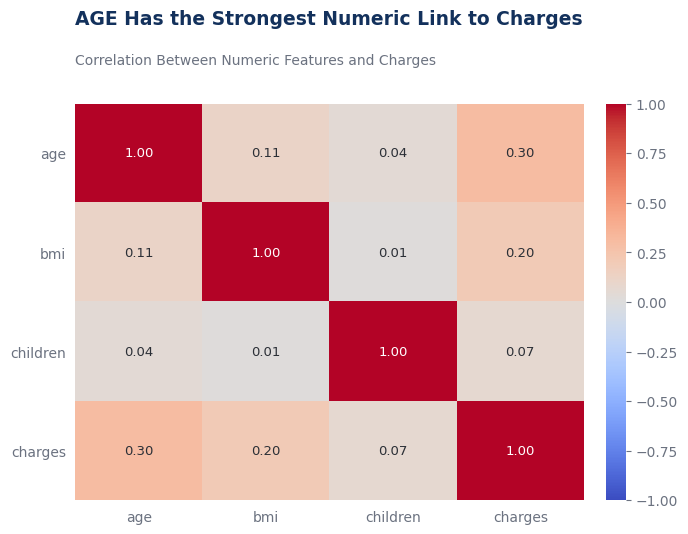

In [ ]:
# Plot the correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(correlation, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.outline.set_visible(False)

ax.set_xticks(range(len(correlation.columns)))
ax.set_xticklabels(correlation.columns, rotation=0)
ax.set_yticks(range(len(correlation.columns)))
ax.set_yticklabels(correlation.columns)
ax.tick_params(left=False, bottom=False)

for i in range(len(correlation)):
    for j in range(len(correlation)):
        value = correlation.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                color="white" if abs(value) > 0.5 else TEXT, fontsize=9.5)

for spine in ax.spines.values():
    spine.set_visible(False)

charge_corrs = correlation["charges"].drop("charges")
top_feature = charge_corrs.abs().idxmax()
chart_title(ax, f"{top_feature.upper()} Has the Strongest Numeric Link to Charges",
            "Correlation Between Numeric Features and Charges")

plt.tight_layout()
plt.show()

## Step 4: Save the cleaned dataset
Exporting `df_clean` to CSV lets this same cleaned data be loaded into SQL (see `medical_insurance_analysis.sql`) for the required SQL analysis, keeping both parts of the project consistent.

In [ ]:
# Save the cleaned dataset to CSV
df_clean.to_csv("medical_insurance_cleaned.csv", index=False)

In [ ]:
# Confirm the file was saved
import os

os.path.exists("medical_insurance_cleaned.csv")

True

In [ ]:
# Print the full file path
print(os.path.abspath("medical_insurance_cleaned.csv"))

/content/medical_insurance_cleaned.csv


In [ ]:
# List the cleaned dataset's columns
df_clean.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'bmi_category', 'age_group'],
      dtype='object')

## Step 5: Prepare the data for modeling
Before we can train a model we need to:
1. Separate the **features** (X — the patient attributes used to predict) from the **target**
   (y — the charge we're trying to predict).
2. Convert categorical columns (sex, smoker, region) into numbers the model can use — this is
   called encoding.
3. Split the data into a **training set** and a **testing set**.

In [ ]:
# Split into features (X) and target (y)

X = df_clean[
    ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
    ]
y = df_clean['charges']

In [ ]:
# Peek at the features
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [ ]:
# Peek at the target
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


`pd.get_dummies` turns categories like "male"/"female" or the four regions into 0/1 columns, since a Linear Regression model can only work with numbers, not text labels.

In [ ]:
# One-hot encode the categorical columns
X_encoded = pd.get_dummies(
    X,
    columns=['sex', 'smoker', 'region'],
    drop_first=True,
    dtype=int
)

X_encoded.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0


**Why split into train and test sets?** If we trained and evaluated the model on the exact same
data, it could just "memorize" the answers and look artificially accurate. Splitting off a test
set (here, 20% of the data) that the model never sees during training lets us check how well it
generalizes to *new* patients — which is what actually matters for pricing real customers.

In [ ]:
# Split into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Confirm the split sizes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1069, 8)
X_test shape: (268, 8)
y_train shape: (1069,)
y_test shape: (268,)


## Step 6: Train the Linear Regression model
The model looks at the training data and learns a formula: `charges ≈ (weight₁ × age) + (weight₂ × BMI) + (weight₃ × smoker) + ...`. Those weights (coefficients) are what the model is "learning."

In [ ]:
# Train the Linear Regression model
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

Using the trained formula, the model now predicts a charge for each patient in the *test* set — patients it has never seen before.

In [ ]:
# Predict charges on the test set
y_pred = linear_model.predict(X_test)


y_pred[:10]

array([ 8143.69388412,  5737.11568259, 14369.31487618, 31745.51363586,
        8962.38665706, 13149.72235307, 30446.76067941,  1453.28881259,
       10633.01840233, 11318.94379361])

In [ ]:
# Build a table comparing actual vs predicted charges
comparison = pd.DataFrame({
    "Actual Charges": y_test.values,
    "Predicted Charges": y_pred
})

comparison.head(10)

,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


In [ ]:
# View the first 10 comparisons
comparison.head(10)

,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


**Actual vs. predicted plot:** if predictions were perfect, every point would sit exactly on the dashed diagonal line. Points scattered around the line (rather than randomly all over the chart) show the model is capturing the main pattern, even if it isn't perfect for every patient.

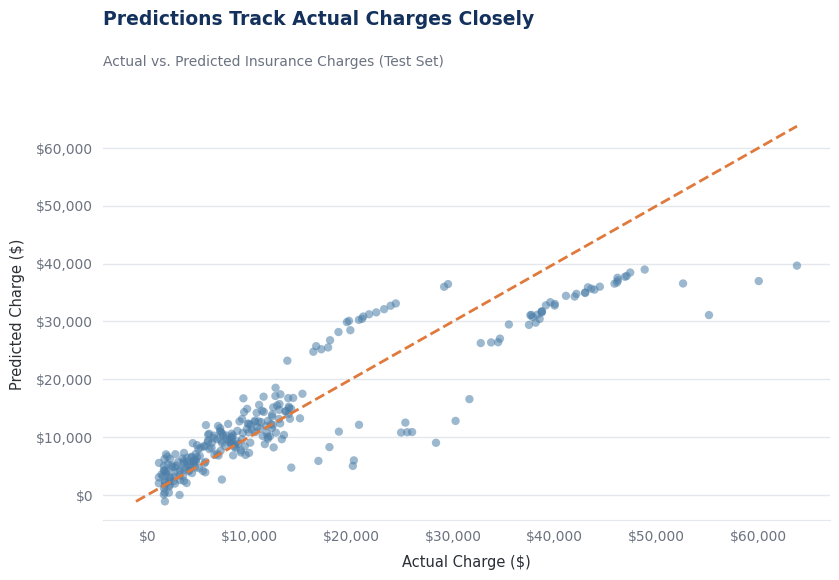

In [ ]:
# Plot actual vs predicted charges
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(y_test, y_pred, alpha=0.55, color=STEEL, edgecolor="none", zorder=3)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
ax.plot([minimum, maximum], [minimum, maximum], color=AMBER, linestyle="--", linewidth=2, zorder=4)

style_axes(ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
chart_title(ax, "Predictions Track Actual Charges Closely",
            "Actual vs. Predicted Insurance Charges (Test Set)")
ax.set_xlabel("Actual Charge ($)", fontsize=10.5, labelpad=8)
ax.set_ylabel("Predicted Charge ($)", fontsize=10.5, labelpad=8)

plt.tight_layout()
plt.show()

**Residual plot:** residuals = actual charge − predicted charge. Ideally these should scatter randomly around zero with no obvious pattern. A funnel or curve shape (as we see here, wider for higher predicted charges) tells us the model is less precise for high-cost patients — common in insurance data because a few very expensive outliers are hard for a simple linear model to capture exactly.

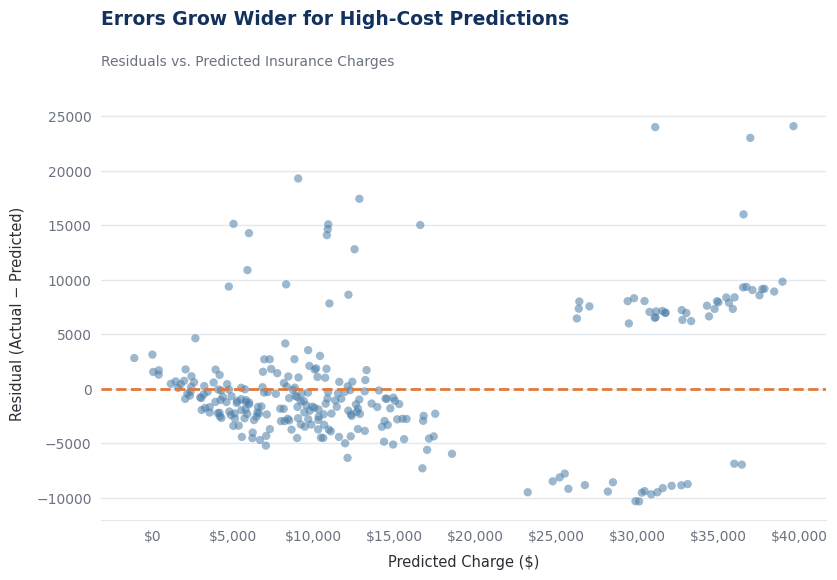

In [ ]:
# Plot the residuals
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(y_pred, residuals, alpha=0.55, color=STEEL, edgecolor="none", zorder=3)
ax.axhline(0, color=AMBER, linestyle="--", linewidth=2, zorder=4)

style_axes(ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
chart_title(ax, "Errors Grow Wider for High-Cost Predictions",
            "Residuals vs. Predicted Insurance Charges")
ax.set_xlabel("Predicted Charge ($)", fontsize=10.5, labelpad=8)
ax.set_ylabel("Residual (Actual − Predicted)", fontsize=10.5, labelpad=8)

plt.tight_layout()
plt.show()

## Step 7: Evaluate the model
- **MAE (Mean Absolute Error):** on average, how far off (in ₦/$) each prediction is from the
  real charge — easiest number to explain to a non-technical stakeholder.
- **RMSE (Root Mean Squared Error):** similar to MAE but penalizes big misses more heavily —
  useful because a few very expensive patients can throw off pricing badly if missed.
- **R² Score:** the percentage of the variation in charges that the model can explain using
  age, BMI, smoking status, etc. An R² of, say, 0.75 means the model explains about 75% of why
  charges differ between patients — the rest comes from factors not in this dataset (e.g.
  pre-existing conditions, family medical history, exact medical claims).

A model doesn't need to be perfect to be useful — even an imperfect R² is a major improvement
over UrbanNest's current rough-estimate pricing, as long as the errors are understood and
communicated.

In [ ]:
# Calculate MAE, RMSE, and R²
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 4177.05
Root Mean Squared Error (RMSE): 5956.34
R² Score: 0.8069


**Coefficients:** each number shows how much charges are predicted to change for a one-unit increase in that feature (holding everything else constant) — e.g. how many extra dollars/naira being a smoker adds to the predicted charge. This is the clearest way to tell the business "which factors matter, and by how much."

In [ ]:
# Pull out the model's coefficients
coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": linear_model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
4,smoker_yes,23077.764593
2,children,533.009989
1,bmi,318.701441
0,age,248.210720
3,sex_male,-101.542054
5,region_northwest,-391.761455
7,region_southwest,-659.139752
6,region_southeast,-838.919616


The chart makes it easy to see at a glance which features push charges up (bars to the right) versus down (bars to the left), and which barely matter at all (bars near zero).

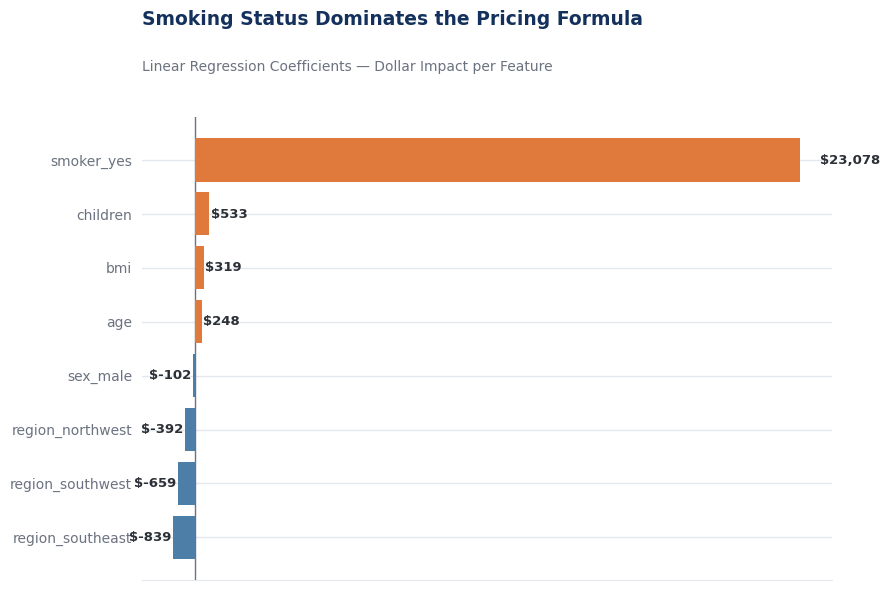

In [ ]:
# Plot the coefficients
coeffs_sorted = coefficients.sort_values("Coefficient")
colors = [AMBER if c > 0 else STEEL for c in coeffs_sorted["Coefficient"]]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(coeffs_sorted["Feature"], coeffs_sorted["Coefficient"], color=colors, zorder=3)

for bar, val in zip(bars, coeffs_sorted["Coefficient"]):
    x_end = bar.get_width()
    align = "left" if x_end >= 0 else "right"
    pad = abs(x_end) * 0.03 + 60
    ax.text(x_end + (pad if x_end >= 0 else -pad), bar.get_y() + bar.get_height()/2,
            f"${x_end:,.0f}", va="center", ha=align, fontsize=9.5, fontweight="bold", color=TEXT)

ax.axvline(0, color=MUTED, linewidth=1, zorder=2)
style_axes(ax)
ax.set_xticks([])
chart_title(ax, "Smoking Status Dominates the Pricing Formula",
            "Linear Regression Coefficients — Dollar Impact per Feature")

plt.tight_layout()
plt.show()

## Step 8: Try the model on three new patients
A quick sanity check — predicting the charge for a hypothetical new patient not in the dataset at all, to confirm the model produces a sensible, realistic number end-to-end.


## New Data

In [ ]:
# Create data for three hypothetical new patients
new_patients_encoded = pd.DataFrame({
    "age":               [40,   29,   55],
    "bmi":               [30.5, 22.0, 34.8],
    "children":          [2,    0,    3],
    "sex_male":          [1,    0,    1],
    "smoker_yes":        [0,    0,    1],
    "region_northwest":  [0,    1,    0],
    "region_southeast":  [1,    0,    0],
    "region_southwest":  [0,    0,    0]
})

new_patients_encoded = new_patients_encoded[X_encoded.columns]

new_patients_encoded

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,40,30.5,2,1,0,0,1,0
1,29,22.0,0,0,0,1,0,0
2,55,34.8,3,1,1,0,0,0


In [ ]:
# Predict each patient's insurance charge
predicted_charges = linear_model.predict(new_patients_encoded)

for i, charge in enumerate(predicted_charges, start=1):
    print(f"Patient {i} — Predicted Insurance Charge: ${charge:,.2f}")

Patient 1 — Predicted Insurance Charge: $8,681.73
Patient 2 — Predicted Insurance Charge: $2,725.13
Patient 3 — Predicted Insurance Charge: $38,225.00


## Summary & recommendations for UrbanNest

- **Smoking status is the single biggest driver of insurance charges**, followed by age and BMI
  (particularly obesity). Region and number of children have a much smaller effect; sex has
  little to no meaningful effect.
- **Smokers with high BMI cost noticeably more than either factor alone would suggest** — the two
  risks compound rather than simply adding up.
- The Linear Regression model explains a solid share of the variation in charges and gives
  UrbanNest a transparent, explainable starting point for data-driven pricing — a clear
  improvement over rough, assumption-based estimates.
- **Recommendation:** use the model's coefficients to build clearer, tiered pricing rules (e.g.
  smoker vs non-smoker, BMI category), and treat the model's error margin (MAE/RMSE) as the
  amount of uncertainty still built into any quote, rather than promising exact pricing.
- **Next steps before submission:** align the age-group bins between the notebook and the SQL
  file, trim the duplicate charts, and decide whether the Random Forest section stays as a bonus
  comparison or moves to an appendix.